# Faster R-CNN F1TENTH Object Detection

This notebook trains a **Faster R-CNN** model on the F1TENTH car detection dataset.

The dataset labels are assumed to be stored in `labels.npy` as `[center_x, center_y, width, height]` in the original `640 x 360` image coordinate system.

## 1. Configuration

In [16]:
from pathlib import Path
import os
import json
import time
import random
import zipfile

import numpy as np
import pandas as pd
import torch
import torchvision
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.lower() == "notebooks" else CURRENT_DIR

DATASET_DIR = PROJECT_ROOT / "data" / "f110_dataset_20220209"

SPLIT_DIR = PROJECT_ROOT / "splits"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
METRIC_DIR = RESULTS_DIR / "metrics"

SEED = 42
TRAIN_FRAC = 0.80

#to be consistent with the yolo image parameters
IMG_WIDTH = 320
IMG_HEIGHT = 180

BATCH_SIZE = 4
EPOCHS = 15
LR = 0.0025
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005
NUM_WORKERS = 0

IOU_THRESHOLD = 0.50
SCORE_THRESHOLDS = [0.30, 0.50, 0.70] #for threshold ablation study
QUALITATIVE_SCORE_THRESHOLD = 0.50

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

for d in [SPLIT_DIR, CHECKPOINT_DIR, FIGURE_DIR, METRIC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Current directory:", CURRENT_DIR)
print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)

Current directory: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\notebooks
Project root: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project
Device: cpu


## 2. Locate or extract the dataset

In [17]:
def find_dataset_dir(project_root, manual_dataset_dir=None):
    # Finds a folder containing labels.npy.
    # Searches the project root, data folders, current folder, and parent folder.
    # If a zip file is found but not extracted, extracts it into project_root/data.
    if manual_dataset_dir is not None:
        manual_dataset_dir = Path(manual_dataset_dir)
        if (manual_dataset_dir / "labels.npy").exists():
            return manual_dataset_dir.resolve()
        raise FileNotFoundError(f"Manual DATASET_DIR does not contain labels.npy: {manual_dataset_dir}")

    search_roots = [
        project_root,
        project_root / "data",
        Path.cwd(),
        Path.cwd().parent,
    ]

    matches = []
    for root in search_roots:
        if root.exists():
            matches.extend(list(root.rglob("labels.npy")))

    matches = sorted(set([m.resolve() for m in matches]))
    if len(matches) > 0:
        return matches[0].parent

    # If labels.npy was not found, search for zip and extract.
    zip_matches = []
    for root in search_roots:
        if root.exists():
            zip_matches.extend(list(root.rglob(f"{DATASET_ZIP_NAME}*.zip")))

    zip_matches = sorted(set([z.resolve() for z in zip_matches]))

    if len(zip_matches) == 0:
        raise FileNotFoundError(
            "Could not find labels.npy or f110_dataset_20220209.zip. "
            "Place the extracted dataset at PROJECT_ROOT/data/f110_dataset_20220209/ "
            "or put the zip file somewhere under the project root."
        )

    zip_path = zip_matches[0]
    extract_dir = project_root / "data"
    extract_dir.mkdir(parents=True, exist_ok=True)

    print("Extracting:", zip_path)
    print("To:", extract_dir)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    matches = list(extract_dir.rglob("labels.npy"))
    if len(matches) == 0:
        raise FileNotFoundError("Extracted zip, but still could not find labels.npy.")

    return matches[0].resolve().parent


dataset_dir = find_dataset_dir(PROJECT_ROOT, DATASET_DIR)
labels_path = dataset_dir / "labels.npy"
labels = np.load(labels_path)

print("Using dataset directory:", dataset_dir)
print("labels.npy shape:", labels.shape)
print("First 5 labels:")
print(labels[:5])

# Basic image check
first_img = dataset_dir / "0.jpg"
print("0.jpg exists:", first_img.exists())

Using dataset directory: C:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\data\f110_dataset_20220209
labels.npy shape: (1792, 4)
First 5 labels:
[[238.5 167.5 147.  103. ]
 [293.  170.5 132.  115. ]
 [313.  148.5  46.   47. ]
 [501.  190.  206.  186. ]
 [350.  200.  206.  190. ]]
0.jpg exists: True


## 3. Create or load the train/validation split

This uses the same `splits/train_indices.npy` and `splits/val_indices.npy` files that your YOLO notebook can use. If they already exist, this notebook reuses them.

In [18]:
train_indices_path = SPLIT_DIR / "train_indices.npy"
val_indices_path = SPLIT_DIR / "val_indices.npy"
split_summary_path = SPLIT_DIR / "split_summary.json"

if train_indices_path.exists() and val_indices_path.exists():
    train_indices = np.load(train_indices_path)
    val_indices = np.load(val_indices_path)
    print("Loaded existing split from:", SPLIT_DIR)
else:
    n = len(labels)
    indices = np.random.default_rng(SEED).permutation(n)
    n_train = int(TRAIN_FRAC * n)

    train_indices = indices[:n_train]
    val_indices = indices[n_train:]

    np.save(train_indices_path, train_indices)
    np.save(val_indices_path, val_indices)

    split_summary = {
        "num_total": int(n),
        "num_train": int(len(train_indices)),
        "num_val": int(len(val_indices)),
        "train_fraction": float(TRAIN_FRAC),
        "seed": int(SEED),
        "dataset_dir": str(dataset_dir),
    }

    with open(split_summary_path, "w") as f:
        json.dump(split_summary, f, indent=2)

    print("Created new split at:", SPLIT_DIR)

print("Train samples:", len(train_indices))
print("Validation samples:", len(val_indices))
print("Overlap count:", len(set(train_indices.tolist()).intersection(set(val_indices.tolist()))))

Loaded existing split from: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\splits
Train samples: 1433
Validation samples: 359
Overlap count: 0


## 4. Dataset class

TorchVision Faster R-CNN expects bounding boxes in `[x_min, y_min, x_max, y_max]` format. The F1TENTH labels are `[center_x, center_y, width, height]`, so this class converts them.

In [19]:
def cxcywh_to_xyxy(box):
    # Convert [cx, cy, w, h] to [x1, y1, x2, y2].
    cx, cy, w, h = box
    x1 = cx - w / 2.0
    y1 = cy - h / 2.0
    x2 = cx + w / 2.0
    y2 = cy + h / 2.0
    return np.array([x1, y1, x2, y2], dtype=np.float32)


class F110FasterRCNNDataset(Dataset):
    def __init__(self, dataset_dir, indices, img_width=320, img_height=180, augment=False):
        self.dataset_dir = Path(dataset_dir)
        self.labels = np.load(self.dataset_dir / "labels.npy").astype(np.float32)
        self.indices = np.asarray(indices, dtype=int)
        self.img_width = int(img_width)
        self.img_height = int(img_height)
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        sample_idx = int(self.indices[idx])
        img_path = self.dataset_dir / f"{sample_idx}.jpg"

        image = Image.open(img_path).convert("RGB")
        original_w, original_h = image.size

        image = image.resize((self.img_width, self.img_height))

        # Label is [cx, cy, w, h] in original image coordinates.
        label = self.labels[sample_idx].copy()

        scale_x = self.img_width / original_w
        scale_y = self.img_height / original_h

        label[0] *= scale_x  # cx
        label[2] *= scale_x  # width
        label[1] *= scale_y  # cy
        label[3] *= scale_y  # height

        box = cxcywh_to_xyxy(label)

        # Clip box to image boundary.
        box[0] = np.clip(box[0], 0, self.img_width - 1)
        box[1] = np.clip(box[1], 0, self.img_height - 1)
        box[2] = np.clip(box[2], 0, self.img_width - 1)
        box[3] = np.clip(box[3], 0, self.img_height - 1)

        image_tensor = torchvision.transforms.functional.to_tensor(image)

        # Simple horizontal flip augmentation for training only.
        if self.augment and random.random() < 0.5:
            image_tensor = torch.flip(image_tensor, dims=[2])
            old_x1 = box[0].copy()
            old_x2 = box[2].copy()
            box[0] = self.img_width - old_x2
            box[2] = self.img_width - old_x1

        # Ensure valid positive-area box.
        x1, y1, x2, y2 = box
        if x2 <= x1:
            x2 = min(self.img_width - 1, x1 + 1)
        if y2 <= y1:
            y2 = min(self.img_height - 1, y1 + 1)

        boxes = torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32)

        # Faster R-CNN class labels: 0 is background, 1 is F1TENTH car.
        class_labels = torch.tensor([1], dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": class_labels,
            "image_id": torch.tensor([sample_idx], dtype=torch.int64),
            "area": torch.tensor([(x2 - x1) * (y2 - y1)], dtype=torch.float32),
            "iscrowd": torch.tensor([0], dtype=torch.int64),
        }

        return image_tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = F110FasterRCNNDataset(
    dataset_dir=dataset_dir,
    indices=train_indices,
    img_width=IMG_WIDTH,
    img_height=IMG_HEIGHT,
    augment=True,
)

val_dataset = F110FasterRCNNDataset(
    dataset_dir=dataset_dir,
    indices=val_indices,
    img_width=IMG_WIDTH,
    img_height=IMG_HEIGHT,
    augment=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=PIN_MEMORY,
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 359
Val batches: 359


## 5. Visualize a sample label

This checks that the label conversion is correct before training.

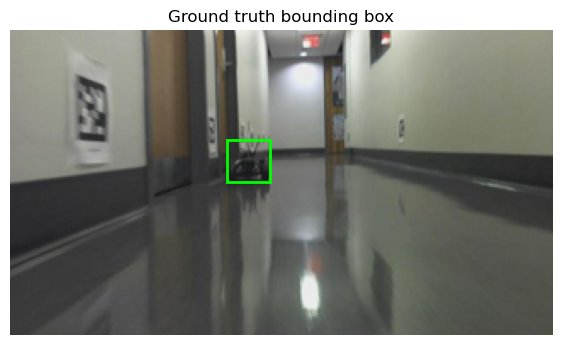

In [20]:
def show_ground_truth_sample(dataset, idx=0):
    image_tensor, target = dataset[idx]
    image_np = image_tensor.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, figsize=(7, 4))
    ax.imshow(image_np)

    for box in target["boxes"].numpy():
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)

    ax.set_title("Ground truth bounding box")
    ax.axis("off")
    plt.show()


show_ground_truth_sample(train_dataset, idx=0)

## 6. Build Faster R-CNN model

This uses a pretrained MobileNetV3-FPN Faster R-CNN model and replaces the final predictor for a 2-class problem: background and F1TENTH car.

In [21]:
def build_fasterrcnn_model(num_classes=2):
    # num_classes includes background.
    # For this dataset: background=0, F1TENTH car=1, so num_classes=2.
    try:
        model = fasterrcnn_mobilenet_v3_large_fpn(
            weights="DEFAULT",
            min_size=IMG_HEIGHT,
            max_size=IMG_WIDTH,
        )
    except TypeError:
        # Compatibility with older torchvision versions.
        model = fasterrcnn_mobilenet_v3_large_fpn(
            pretrained=True,
            min_size=IMG_HEIGHT,
            max_size=IMG_WIDTH,
        )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


model = build_fasterrcnn_model(num_classes=2)
model.to(DEVICE)

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=4,
    gamma=0.5,
)

print(model.roi_heads.box_predictor)

FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=2, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=8, bias=True)
)


## 7. Training utilities

In [22]:
def move_targets_to_device(targets, device):
    return [{k: v.to(device) for k, v in target.items()} for target in targets]


def train_one_epoch(model, data_loader, optimizer, device):
    model.train()
    losses = []
    loss_components = []

    for images, targets in tqdm(data_loader, desc="Training", leave=False):
        images = [img.to(device) for img in images]
        targets = move_targets_to_device(targets, device)

        loss_dict = model(images, targets)
        total_loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        losses.append(float(total_loss.item()))
        loss_components.append({k: float(v.item()) for k, v in loss_dict.items()})

    return float(np.mean(losses)), loss_components


@torch.no_grad()
def compute_validation_loss(model, data_loader, device):
    # TorchVision detection models return losses only in train mode.
    # We use train mode under no_grad for validation loss, then use eval mode for prediction metrics.
    model.train()
    losses = []

    for images, targets in tqdm(data_loader, desc="Validation loss", leave=False):
        images = [img.to(device) for img in images]
        targets = move_targets_to_device(targets, device)

        loss_dict = model(images, targets)
        total_loss = sum(loss for loss in loss_dict.values())
        losses.append(float(total_loss.item()))

    return float(np.mean(losses))

## 8. Train Faster R-CNN

In [23]:
train_loss_record = []
val_loss_record = []

best_val_loss = float("inf")
best_epoch = -1

start_time = time.time()

for epoch in range(EPOCHS):
    train_loss, component_losses = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss = compute_validation_loss(model, val_loader, DEVICE)

    lr_scheduler.step()

    train_loss_record.append(train_loss)
    val_loss_record.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), CHECKPOINT_DIR / "fasterrcnn_best.pt")

torch.save(model.state_dict(), CHECKPOINT_DIR / "fasterrcnn_last.pt")

elapsed = time.time() - start_time
print(f"Training completed in {elapsed/60:.2f} minutes.")
print("Best epoch:", best_epoch, "Best validation loss:", best_val_loss)

np.save(METRIC_DIR / "fasterrcnn_loss.npy", [np.array(train_loss_record), np.array(val_loss_record)])

Training:   0%|          | 0/359 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/359 [00:00<?, ?it/s]

Epoch 01/15 | train_loss=0.7262 | val_loss=0.6155 | lr=0.002500


Training:   0%|          | 0/359 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/359 [00:00<?, ?it/s]

...

Validation loss:   0%|          | 0/359 [00:00<?, ?it/s]

Epoch 14/15 | train_loss=0.2141 | val_loss=0.2857 | lr=0.000313


Training:   0%|          | 0/359 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/359 [00:00<?, ?it/s]

Epoch 15/15 | train_loss=0.2202 | val_loss=0.2820 | lr=0.000313
Training completed in 102.62 minutes.
Best epoch: 15 Best validation loss: 0.2820152092289211


## 9. Plot and save training curves

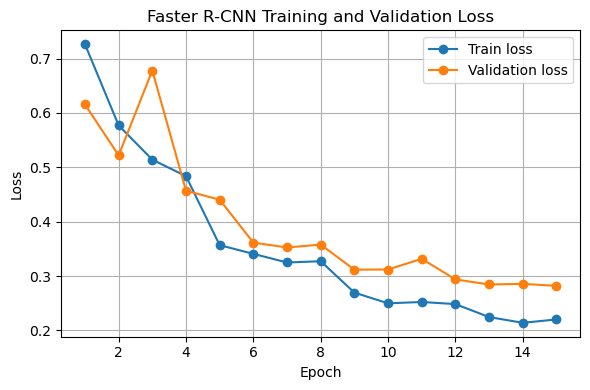

Saved: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\results\figures\fasterrcnn_loss.png


In [24]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(train_loss_record) + 1), train_loss_record, marker="o", label="Train loss")
plt.plot(range(1, len(val_loss_record) + 1), val_loss_record, marker="o", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Faster R-CNN Training and Validation Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()

loss_fig_path = FIGURE_DIR / "fasterrcnn_loss.png"
plt.savefig(loss_fig_path, dpi=200)
plt.show()

print("Saved:", loss_fig_path)

## 10. Evaluation metrics

This reports AP@0.50, precision, recall, mean matched IoU, and inference time.

In [25]:
def box_iou_matrix(boxes_a, boxes_b):
    # boxes_a: [N, 4]
    # boxes_b: [M, 4]
    # returns IoU matrix [N, M]
    if len(boxes_a) == 0 or len(boxes_b) == 0:
        return np.zeros((len(boxes_a), len(boxes_b)), dtype=np.float32)

    a = np.asarray(boxes_a, dtype=np.float32)
    b = np.asarray(boxes_b, dtype=np.float32)

    x1 = np.maximum(a[:, None, 0], b[None, :, 0])
    y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2])
    y2 = np.minimum(a[:, None, 3], b[None, :, 3])

    inter = np.maximum(0, x2 - x1) * np.maximum(0, y2 - y1)

    area_a = np.maximum(0, a[:, 2] - a[:, 0]) * np.maximum(0, a[:, 3] - a[:, 1])
    area_b = np.maximum(0, b[:, 2] - b[:, 0]) * np.maximum(0, b[:, 3] - b[:, 1])

    union = area_a[:, None] + area_b[None, :] - inter + 1e-9
    return inter / union


@torch.no_grad()
def evaluate_detector(model, data_loader, device, score_threshold=0.5, iou_threshold=0.5):
    model.eval()

    all_scores = []
    all_tp = []
    all_fp = []
    matched_ious = []
    total_gt = 0
    inference_times = []

    for images, targets in tqdm(data_loader, desc=f"Evaluating thr={score_threshold}", leave=False):
        images = [img.to(device) for img in images]

        if device.type == "cuda":
            torch.cuda.synchronize()

        t0 = time.time()
        outputs = model(images)

        if device.type == "cuda":
            torch.cuda.synchronize()

        inference_times.append((time.time() - t0) / len(images))

        for output, target in zip(outputs, targets):
            gt_boxes = target["boxes"].cpu().numpy()
            total_gt += len(gt_boxes)

            pred_boxes = output["boxes"].detach().cpu().numpy()
            pred_scores = output["scores"].detach().cpu().numpy()

            keep = pred_scores >= score_threshold
            pred_boxes = pred_boxes[keep]
            pred_scores = pred_scores[keep]

            order = np.argsort(-pred_scores)
            pred_boxes = pred_boxes[order]
            pred_scores = pred_scores[order]

            used_gt = set()
            ious = box_iou_matrix(pred_boxes, gt_boxes)

            for pred_i in range(len(pred_boxes)):
                all_scores.append(float(pred_scores[pred_i]))

                if len(gt_boxes) == 0:
                    all_tp.append(0)
                    all_fp.append(1)
                    continue

                best_gt_i = int(np.argmax(ious[pred_i]))
                best_iou = float(ious[pred_i, best_gt_i])

                if best_iou >= iou_threshold and best_gt_i not in used_gt:
                    all_tp.append(1)
                    all_fp.append(0)
                    used_gt.add(best_gt_i)
                    matched_ious.append(best_iou)
                else:
                    all_tp.append(0)
                    all_fp.append(1)

    if len(all_scores) == 0:
        return {
            "score_threshold": score_threshold,
            "AP50": 0.0,
            "precision": 0.0,
            "recall": 0.0,
            "mean_matched_iou": 0.0,
            "mean_inference_ms": 1000.0 * float(np.mean(inference_times)),
            "num_predictions": 0,
            "num_ground_truth": int(total_gt),
        }

    all_scores = np.asarray(all_scores)
    all_tp = np.asarray(all_tp)
    all_fp = np.asarray(all_fp)

    order = np.argsort(-all_scores)
    all_tp = all_tp[order]
    all_fp = all_fp[order]

    cum_tp = np.cumsum(all_tp)
    cum_fp = np.cumsum(all_fp)

    precision_curve = cum_tp / np.maximum(cum_tp + cum_fp, 1)
    recall_curve = cum_tp / max(total_gt, 1)

    # VOC-style AP using 101 recall thresholds.
    ap = 0.0
    for r in np.linspace(0, 1, 101):
        if np.any(recall_curve >= r):
            ap += np.max(precision_curve[recall_curve >= r]) / 101.0

    precision = float(cum_tp[-1] / max(cum_tp[-1] + cum_fp[-1], 1))
    recall = float(cum_tp[-1] / max(total_gt, 1))

    return {
        "score_threshold": score_threshold,
        "AP50": float(ap),
        "precision": precision,
        "recall": recall,
        "mean_matched_iou": float(np.mean(matched_ious)) if len(matched_ious) > 0 else 0.0,
        "mean_inference_ms": 1000.0 * float(np.mean(inference_times)),
        "num_predictions": int(len(all_scores)),
        "num_ground_truth": int(total_gt),
    }

## 11. Run final evaluation and threshold ablation

In [26]:
# Load the best checkpoint before final evaluation.
best_ckpt = CHECKPOINT_DIR / "fasterrcnn_best.pt"
if best_ckpt.exists():
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    print("Loaded best checkpoint:", best_ckpt)

rows = []
for threshold in SCORE_THRESHOLDS:
    metrics = evaluate_detector(
        model=model,
        data_loader=val_loader,
        device=DEVICE,
        score_threshold=threshold,
        iou_threshold=IOU_THRESHOLD,
    )
    rows.append(metrics)

metrics_df = pd.DataFrame(rows)
metrics_csv_path = METRIC_DIR / "fasterrcnn_threshold_ablation.csv"
metrics_df.to_csv(metrics_csv_path, index=False)

display(metrics_df)
print("Saved:", metrics_csv_path)

# Also save the standard threshold=0.50 row separately for the comparison table.
main_metrics = metrics_df[metrics_df["score_threshold"] == 0.50]
if len(main_metrics) > 0:
    main_metrics.to_csv(METRIC_DIR / "fasterrcnn_metrics.csv", index=False)
    print("Saved:", METRIC_DIR / "fasterrcnn_metrics.csv")

Loaded best checkpoint: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\checkpoints\fasterrcnn_best.pt


Evaluating thr=0.3:   0%|          | 0/359 [00:00<?, ?it/s]

Evaluating thr=0.5:   0%|          | 0/359 [00:00<?, ?it/s]

Evaluating thr=0.7:   0%|          | 0/359 [00:00<?, ?it/s]

,score_threshold,AP50,precision,recall,mean_matched_iou,mean_inference_ms,num_predictions,num_ground_truth
0,0.3,1.0,0.972900,1.0,0.942292,170.100515,369,359
1,0.5,1.0,0.983562,1.0,0.942292,129.008738,365,359
2,0.7,1.0,0.986264,1.0,0.942292,93.268561,364,359


Saved: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\results\metrics\fasterrcnn_threshold_ablation.csv
Saved: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\results\metrics\fasterrcnn_metrics.csv


## 12. Plot threshold ablation

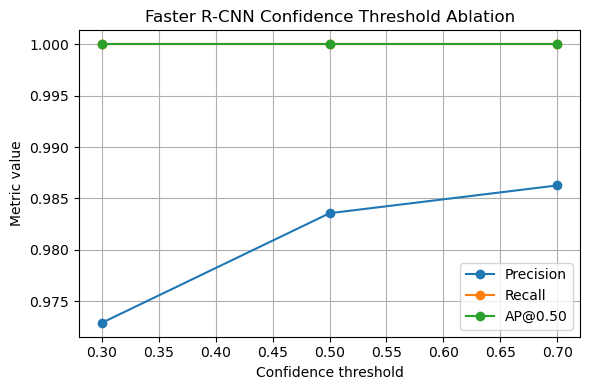

Saved: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\results\figures\fasterrcnn_threshold_ablation.png


In [27]:
plt.figure(figsize=(6, 4))
plt.plot(metrics_df["score_threshold"], metrics_df["precision"], marker="o", label="Precision")
plt.plot(metrics_df["score_threshold"], metrics_df["recall"], marker="o", label="Recall")
plt.plot(metrics_df["score_threshold"], metrics_df["AP50"], marker="o", label="AP@0.50")
plt.xlabel("Confidence threshold")
plt.ylabel("Metric value")
plt.title("Faster R-CNN Confidence Threshold Ablation")
plt.grid(True)
plt.legend()
plt.tight_layout()

ablation_fig_path = FIGURE_DIR / "fasterrcnn_threshold_ablation.png"
plt.savefig(ablation_fig_path, dpi=200)
plt.show()

print("Saved:", ablation_fig_path)

## 13. Qualitative detections

Green boxes are ground truth. Blue boxes are Faster R-CNN predictions.

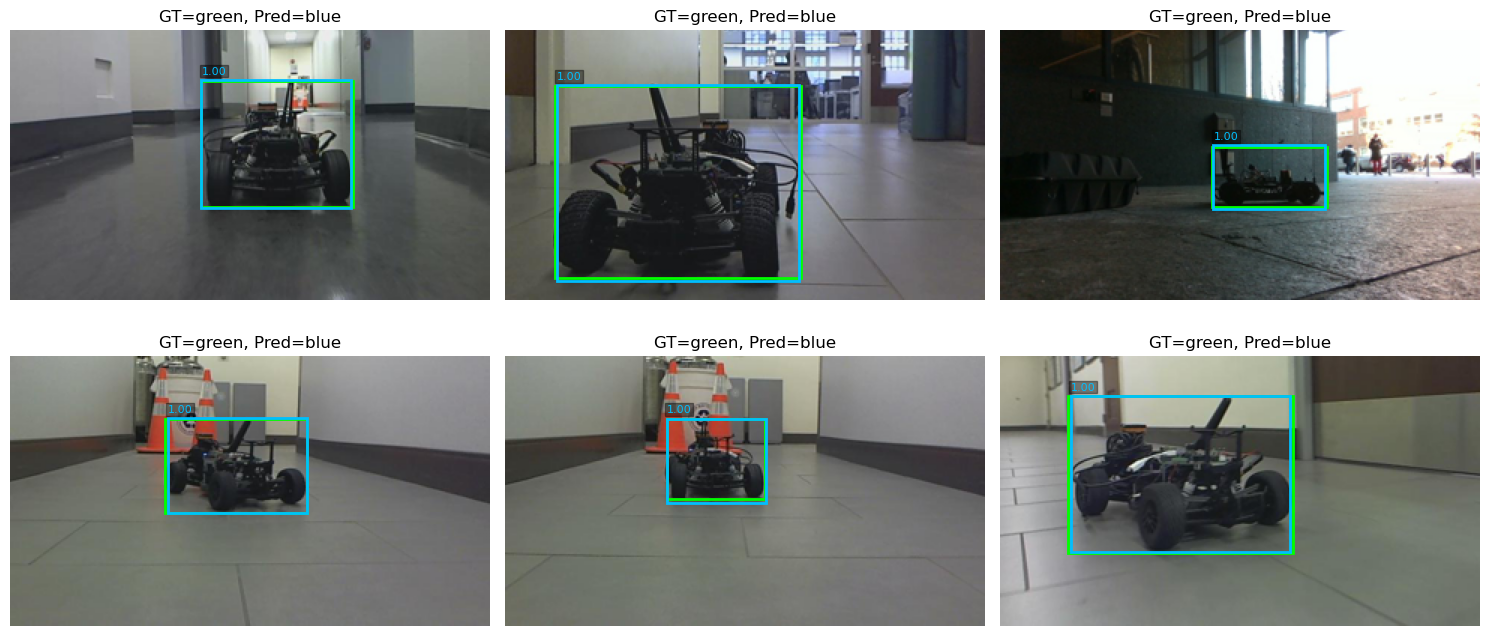

Saved: c:\Users\ishan\OneDrive\Desktop\Code\deep_learning_project\results\figures\fasterrcnn_predictions.png


In [28]:
@torch.no_grad()
def show_predictions(model, dataset, device, num_images=6, score_threshold=0.5):
    model.eval()

    num_images = min(num_images, len(dataset))
    sample_indices = np.random.default_rng(SEED).choice(len(dataset), size=num_images, replace=False)

    cols = min(3, num_images)
    rows = int(np.ceil(num_images / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax_i, dataset_i in enumerate(sample_indices):
        ax = axes[ax_i]

        image_tensor, target = dataset[int(dataset_i)]
        output = model([image_tensor.to(device)])[0]

        image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
        ax.imshow(image_np)

        # Ground truth: green
        for box in target["boxes"].cpu().numpy():
            x1, y1, x2, y2 = box
            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="lime",
                facecolor="none",
            )
            ax.add_patch(rect)

        # Predictions: blue
        pred_boxes = output["boxes"].detach().cpu().numpy()
        pred_scores = output["scores"].detach().cpu().numpy()

        for box, score in zip(pred_boxes, pred_scores):
            if score < score_threshold:
                continue

            x1, y1, x2, y2 = box
            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                linewidth=2,
                edgecolor="deepskyblue",
                facecolor="none",
            )
            ax.add_patch(rect)
            ax.text(
                x1,
                max(0, y1 - 4),
                f"{score:.2f}",
                color="deepskyblue",
                fontsize=8,
                bbox=dict(facecolor="black", alpha=0.4, pad=1),
            )

        ax.set_title("GT=green, Pred=blue")
        ax.axis("off")

    for ax_i in range(num_images, len(axes)):
        axes[ax_i].axis("off")

    plt.tight_layout()
    return fig


fig = show_predictions(
    model=model,
    dataset=val_dataset,
    device=DEVICE,
    num_images=6,
    score_threshold=QUALITATIVE_SCORE_THRESHOLD,
)

qual_fig_path = FIGURE_DIR / "fasterrcnn_predictions.png"
fig.savefig(qual_fig_path, dpi=200)
plt.show()

print("Saved:", qual_fig_path)